In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
meddata = pd.read_csv("Insurance.csv")
meddata.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
meddata.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Axes: xlabel='sex', ylabel='charges'>

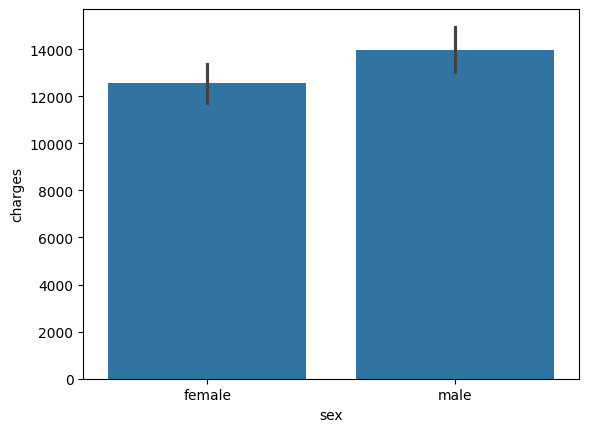

In [5]:
sns.barplot(x = 'sex', y ='charges', data = meddata)

<Axes: xlabel='sex', ylabel='charges'>

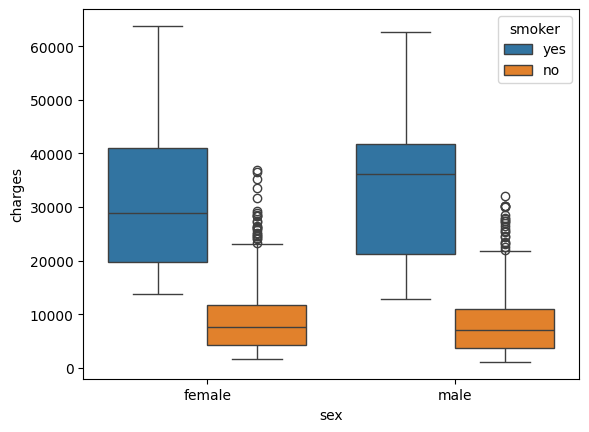

In [6]:
sns.boxplot(x= 'sex', y='charges', hue='smoker', data = meddata)

/tmp/ipykernel_3473/1632767954.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(meddata['charges'], bins = 50)


<Axes: xlabel='charges', ylabel='Density'>

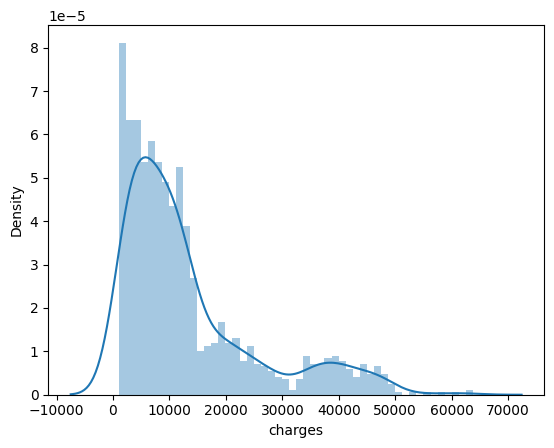

In [7]:
sns.distplot(meddata['charges'], bins = 50)

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
meddata['sex'] =  le.fit_transform(meddata['sex'])
meddata['region'] =  le.fit_transform(meddata['region'])
meddata['smoker'] =  le.fit_transform(meddata['smoker'])
print(meddata)

      age  sex     bmi  children  smoker  region      charges
0      19    0  27.900         0       1       3  16884.92400
1      18    1  33.770         1       0       2   1725.55230
2      28    1  33.000         3       0       2   4449.46200
3      33    1  22.705         0       0       1  21984.47061
4      32    1  28.880         0       0       1   3866.85520
...   ...  ...     ...       ...     ...     ...          ...
1333   50    1  30.970         3       0       1  10600.54830
1334   18    0  31.920         0       0       0   2205.98080
1335   18    0  36.850         0       0       2   1629.83350
1336   21    0  25.800         0       0       3   2007.94500
1337   61    0  29.070         0       1       1  29141.36030

[1338 rows x 7 columns]


In [12]:
X = meddata.iloc[:,:-1].values
y = meddata.iloc[:,-1].values

In [13]:
print(X)

[[19.    0.   27.9   0.    1.    3.  ]
 [18.    1.   33.77  1.    0.    2.  ]
 [28.    1.   33.    3.    0.    2.  ]
 ...
 [18.    0.   36.85  0.    0.    2.  ]
 [21.    0.   25.8   0.    0.    3.  ]
 [61.    0.   29.07  0.    1.    1.  ]]


In [14]:
print(y)

[16884.924   1725.5523  4449.462  ...  1629.8335  2007.945  29141.3603]


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
tr_r2 = model.score(X_train,y_train)
print("Training R^2 = ",tr_r2)
ts_r2 = model.score(X_test,y_test)
print("Testing R^2 = ",ts_r2)

Training R^2 =  0.7417049283233981
Testing R^2 =  0.7833463107364539


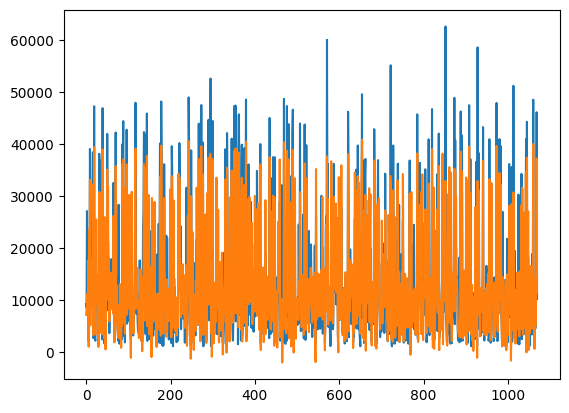

In [25]:
y_pred=model.predict(X_train)
plt.plot(y_train)
plt.plot(y_pred)
plt.show()

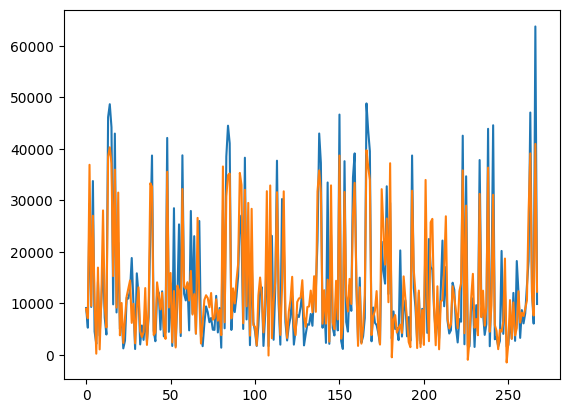

In [26]:
y_pred = model.predict(X_test)
plt.plot(y_test)
plt.plot(y_pred)
plt.show()

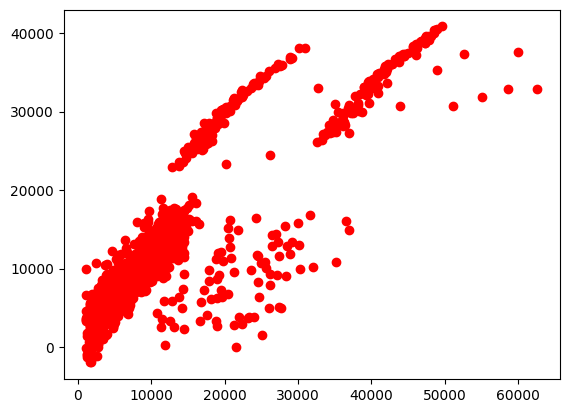

In [27]:
plt.scatter(y_train,model.predict(X_train),color = 'red')

In [28]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train,y_train)
tr_r2 = model.score(X_train,y_train)
print("Training R^2 = ",tr_r2)
ts_r2 = model.score(X_test,y_test)
print("Testing R^2 = ",ts_r2)

Training R^2 =  0.9750878871889546
Testing R^2 =  0.862813024284233


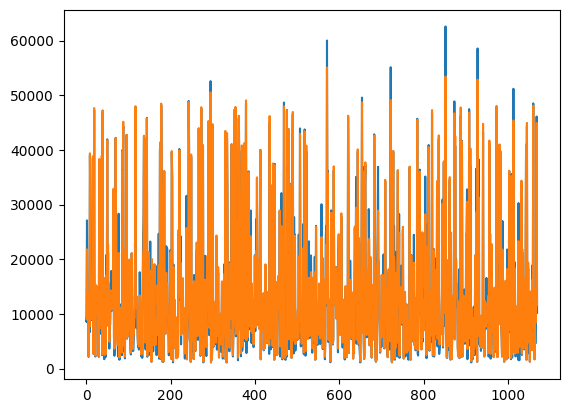

In [29]:
y_pred = model.predict(X_train)
plt.plot(y_train)
plt.plot(y_pred)
plt.show()

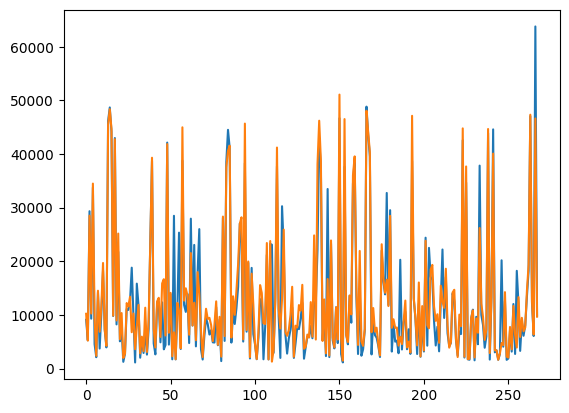

In [30]:
y_pred = model.predict(X_test)
plt.plot(y_test)
plt.plot(y_pred)
plt.show()

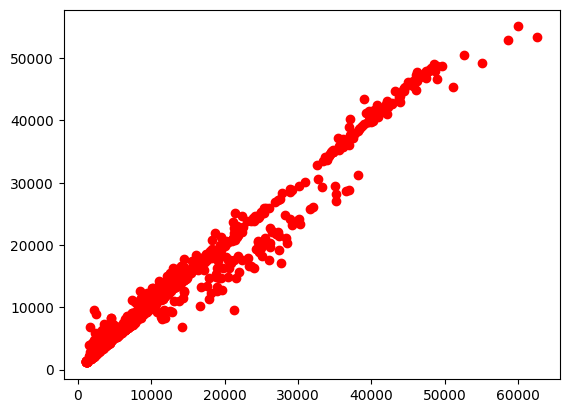

In [31]:
plt.scatter(y_train,model.predict(X_train),color = 'red')

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor()
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    tr_r2 = model.score(X_train, y_train)
    ts_r2 = model.score(X_test, y_test)
    results[name] = {'Training R^2': tr_r2, 'Testing R^2': ts_r2}

print("\n--- Model Comparison ---")
for name, scores in results.items():
    print(f"{name}:")
    print(f"  Training R^2 = {scores['Training R^2']:.4f}")
    print(f"  Testing R^2 = {scores['Testing R^2']:.4f}")

Training Linear Regression...
Training Random Forest Regressor...
Training Decision Tree Regressor...
Training Gradient Boosting Regressor...
Training Support Vector Regressor...
Training K-Nearest Neighbors Regressor...

--- Model Comparison ---
Linear Regression:
  Training R^2 = 0.7417
  Testing R^2 = 0.7833
Random Forest Regressor:
  Training R^2 = 0.9743
  Testing R^2 = 0.8643
Decision Tree Regressor:
  Training R^2 = 0.9983
  Testing R^2 = 0.6844
Gradient Boosting Regressor:
  Training R^2 = 0.8980
  Testing R^2 = 0.8780
Support Vector Regressor:
  Training R^2 = -0.0977
  Testing R^2 = -0.0723
K-Nearest Neighbors Regressor:
  Training R^2 = 0.3942
  Testing R^2 = 0.1463


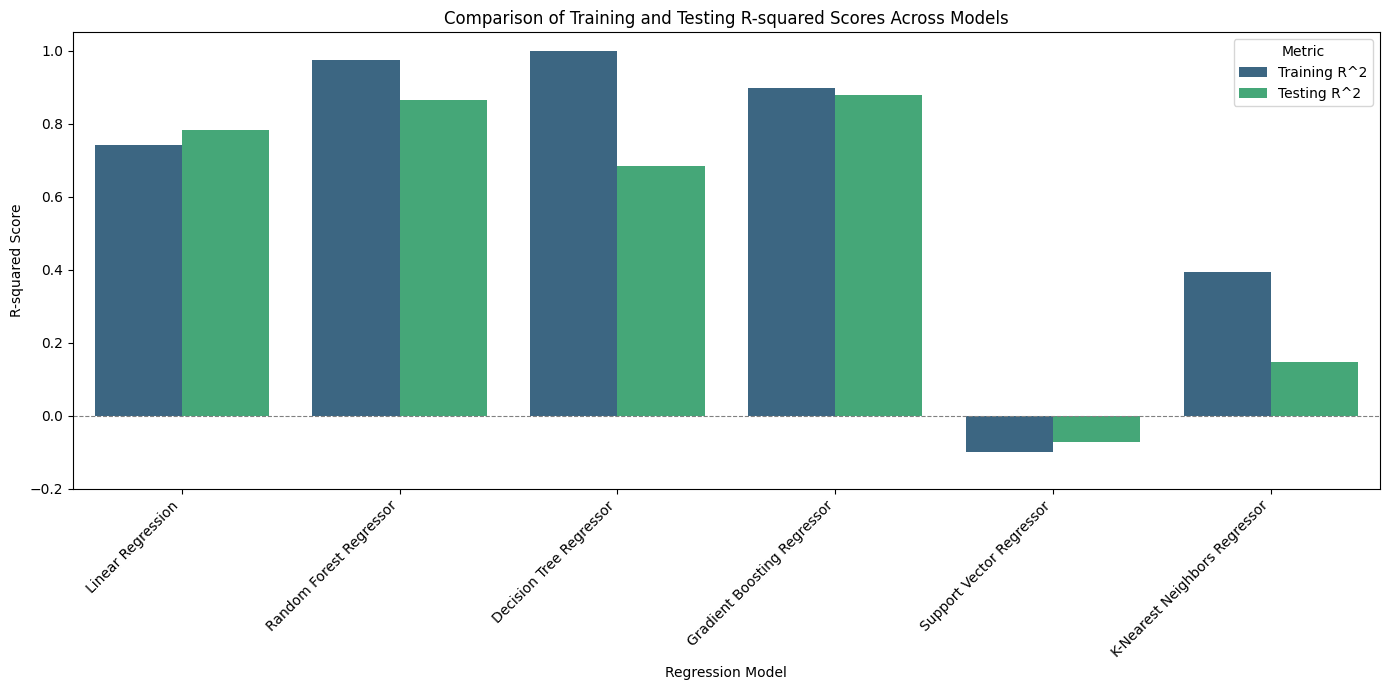

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert results dictionary to a DataFrame for easier plotting
plot_data = []
for model_name, scores in results.items():
    plot_data.append({'Model': model_name, 'Metric': 'Training R^2', 'Score': scores['Training R^2']})
    plot_data.append({'Model': model_name, 'Metric': 'Testing R^2', 'Score': scores['Testing R^2']})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_df, palette='viridis')
plt.title('Comparison of Training and Testing R-squared Scores Across Models')
plt.xlabel('Regression Model')
plt.ylabel('R-squared Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(-0.2, 1.05) # Set y-axis limits to better visualize R^2 range
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a line at R^2 = 0
plt.legend(title='Metric')
plt.tight_layout()
plt.show()